In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [3]:
df = pd.read_csv('data/athlete_events.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
#info 
print(f"num of notes : {len(df)}")
print(f"columns: {df.columns.tolist()}")
df.info()

num of notes : 271116
columns: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [7]:
athletics = df[df['Sport'] == 'Athletics'].copy(deep=True)
athletics.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN
27,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 4 x 100 metres Relay,NaN
57,18,Timo Antero Aaltonen,M,31.0,189.0,130.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Men's Shot Put,NaN
94,31,Evald rma (rman-),M,24.0,174.0,70.0,Estonia,EST,1936 Summer,1936,Summer,Berlin,Athletics,Athletics Men's Pole Vault,NaN
95,32,Olav Augunson Aarnes,M,23.0,NaN,NaN,Norway,NOR,1912 Summer,1912,Summer,Stockholm,Athletics,Athletics Men's High Jump,NaN


In [11]:
print(athletics['Event'].value_counts().head(20))
print(f"\n num of disciplines : {athletics['Event'].nunique()}")

Event
Athletics Men's Marathon                  2093
Athletics Men's 100 metres                1936
Athletics Men's 4 x 100 metres Relay      1910
Athletics Men's 4 x 400 metres Relay      1749
Athletics Men's 200 metres                1495
Athletics Men's 400 metres                1417
Athletics Men's 800 metres                1321
Athletics Women's 4 x 100 metres Relay    1174
Athletics Men's 1,500 metres              1162
Athletics Women's 100 metres              1063
Athletics Men's 5,000 metres               982
Athletics Men's Long Jump                  954
Athletics Men's 110 metres Hurdles         896
Athletics Men's High Jump                  865
Athletics Men's 10,000 metres              850
Athletics Men's Triple Jump                847
Athletics Men's Discus Throw               834
Athletics Men's 400 metres Hurdles         821
Athletics Men's 50 kilometres Walk         773
Athletics Women's 200 metres               765
Name: count, dtype: int64

 num of disciplines : 83


In [15]:
#cleaning data

athletics_clean = athletics.dropna(subset=['Height', 'Weight']).copy(deep=True)
athletics_clean['BMI'] = athletics_clean['Weight'] / ((athletics_clean['Height'] / 100) ** 2)
athletics_clean.head()
                                   

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,BMI
57,18,Timo Antero Aaltonen,M,31.0,189.0,130.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Men's Shot Put,NaN,36.393158
94,31,Evald rma (rman-),M,24.0,174.0,70.0,Estonia,EST,1936 Summer,1936,Summer,Berlin,Athletics,Athletics Men's Pole Vault,NaN,23.120624
98,34,Jamale (Djamel-) Aarrass (Ahrass-),M,30.0,187.0,76.0,France,FRA,2012 Summer,2012,Summer,London,Athletics,"Athletics Men's 1,500 metres",NaN,21.733535
130,47,Erling Rudolf Aastad,M,22.0,177.0,74.0,Norway,NOR,1920 Summer,1920,Summer,Antwerpen,Athletics,Athletics Men's 4 x 100 metres Relay,NaN,23.620288
131,47,Erling Rudolf Aastad,M,22.0,177.0,74.0,Norway,NOR,1920 Summer,1920,Summer,Antwerpen,Athletics,Athletics Men's Long Jump,NaN,23.620288


In [23]:
print(f"notes before cleaning : {len(athletics)}\n")
print(f"notes after cleaning : {len(athletics_clean)}\n")
print(f"lost notes : {len(athletics) - len(athletics_clean)};\nдоля : {((len(athletics) - len(athletics_clean))/len(athletics)*100):.1f}%\n")

notes before cleaning : 38624

notes after cleaning : 32568

lost notes : 6056;
доля : 15.7%



In [31]:
#compare the growth of athletes in different disciplines
men = athletics_clean[athletics_clean['Sex'] == 'M'].copy(deep=True)
women = athletics_clean[athletics_clean['Sex'] == 'F'].copy(deep=True)
women.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,BMI
135,49,Moonika Aava,F,24.0,168.0,65.0,Estonia,EST,2004 Summer,2004,Summer,Athina,Athletics,Athletics Women's Javelin Throw,NaN,23.030045
136,49,Moonika Aava,F,28.0,168.0,65.0,Estonia,EST,2008 Summer,2008,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,NaN,23.030045
163,67,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.0,80.0,Russia,RUS,2008 Summer,2008,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,Silver,24.968010
164,67,Mariya Vasilyevna Abakumova (-Tarabina),F,26.0,179.0,80.0,Russia,RUS,2012 Summer,2012,Summer,London,Athletics,Athletics Women's Javelin Throw,NaN,24.968010
193,88,Nunu Dzhansuhivna Abashydze (-Myslaieva),F,25.0,168.0,105.0,Soviet Union,URS,1980 Summer,1980,Summer,Moskva,Athletics,Athletics Women's Shot Put,NaN,37.202381


In [26]:
def plot_top_events_by_height(data, sex_name, color):
    height_by_event = data.groupby('Event')['Height'].agg(['mean', 'count', 'std']).round(1)
    height_by_event = height_by_event[height_by_event['count'] > 30] #only popular
    height_by_event = height_by_event.sort_values('mean', ascending=False) #sort mean by descent

    top_20 = height_by_event.head(20)

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_20)), top_20['mean'], xerr=top_20['std'], capsize=3, color=color, alpha=0.7)
    plt.yticks(range(len(top_20)), top_20.index)
    plt.xlabel('Mean height (sm)')
    plt.title(f'Top-20 events in t&f by height - {sex_name}')
    
    for i, (idx, row) in enumerate(top_20.iterrows()):
        plt.text(row['mean'] + 1, i, f"{row['mean']} см", va='center')
    
    plt.tight_layout()
    plt.show()
    
    return top_20

MENS


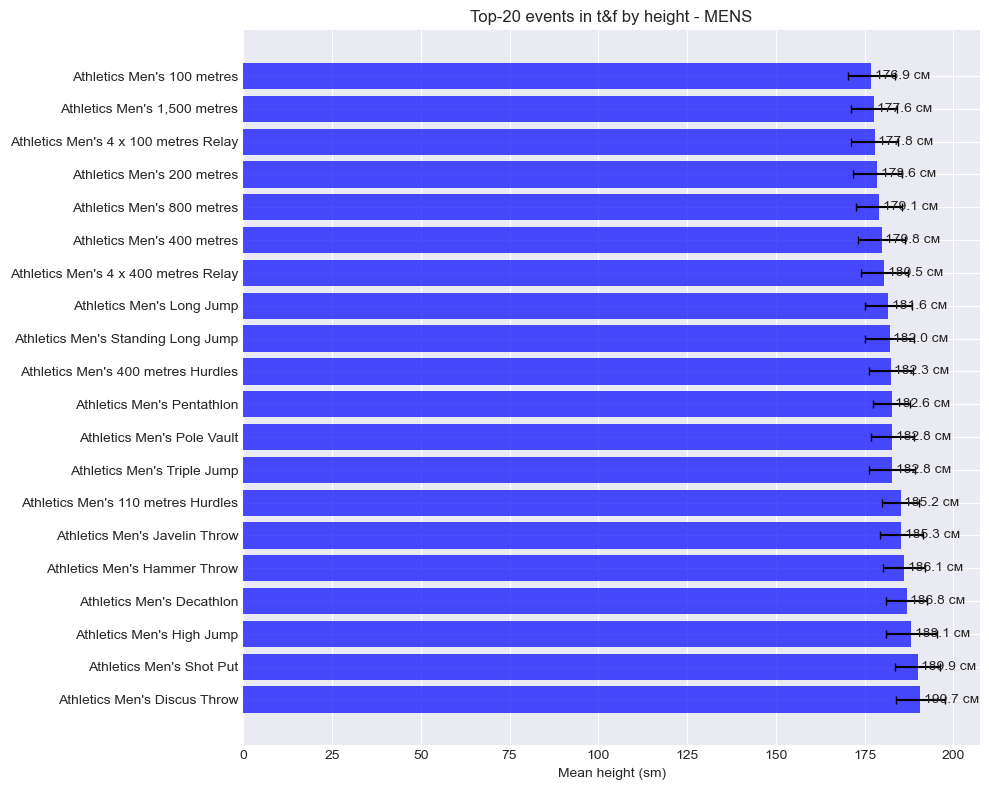

In [27]:
print("="*50)
print("MENS")
print("="*50)
men_top = plot_top_events_by_height(men, "MENS", "blue")

WOMENS


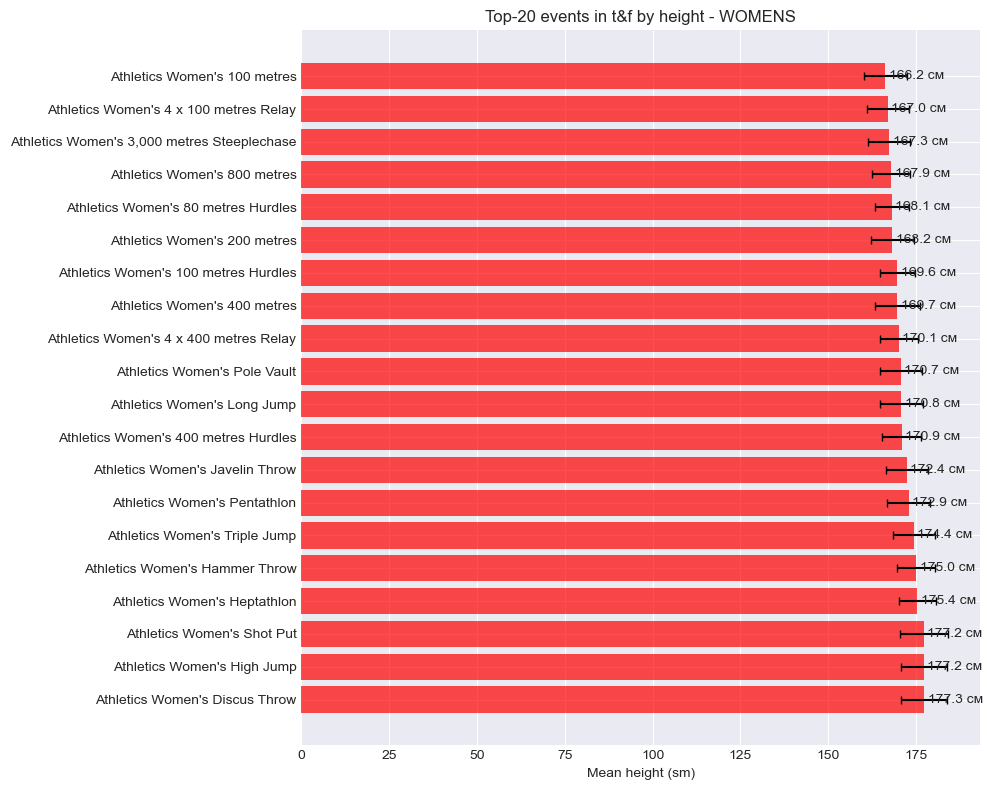

In [32]:
print("="*50)
print("WOMENS")
print("="*50)
women_top = plot_top_events_by_height(women, "WOMENS", "red")

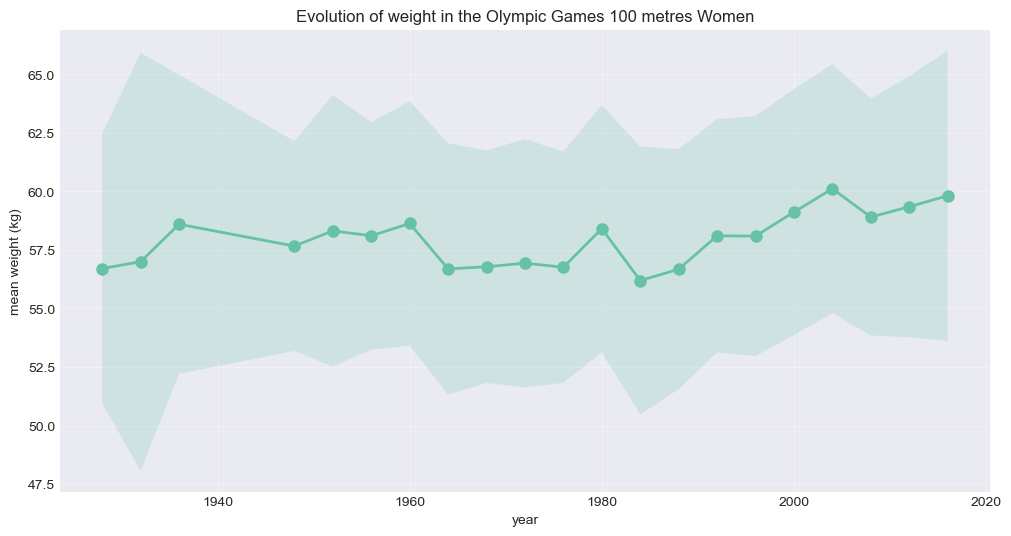

С 1928 по 2016 weight up for 3.1 kg


In [36]:
hundred_metres = athletics_clean[(athletics_clean['Event'].str.contains('100 metres')) & (athletics_clean['Sex'] == 'F') & (~(athletics_clean['Event'].str.contains('hurdles')))]

weight_by_year = hundred_metres.groupby('Year')['Weight'].agg(['mean', 'std', 'count'])
weight_by_year = weight_by_year[weight_by_year['count'] > 5]  #only not empty

plt.figure(figsize=(12, 6))
plt.plot(weight_by_year.index, weight_by_year['mean'], 'o-', linewidth=2, markersize=8)
plt.fill_between(weight_by_year.index, 
                 weight_by_year['mean'] - weight_by_year['std'],
                 weight_by_year['mean'] + weight_by_year['std'],
                 alpha=0.2)
plt.xlabel('year')
plt.ylabel('mean weight (kg)')
plt.title('Evolution of weight in the Olympic Games 100 metres Women')
plt.grid(True, alpha=0.3)
plt.show()

first_year = weight_by_year.iloc[0]
last_year = weight_by_year.iloc[-1]
change = last_year['mean'] - first_year['mean']
print(f"С {first_year.name} по {last_year.name} weight up for {change:.1f} kg")

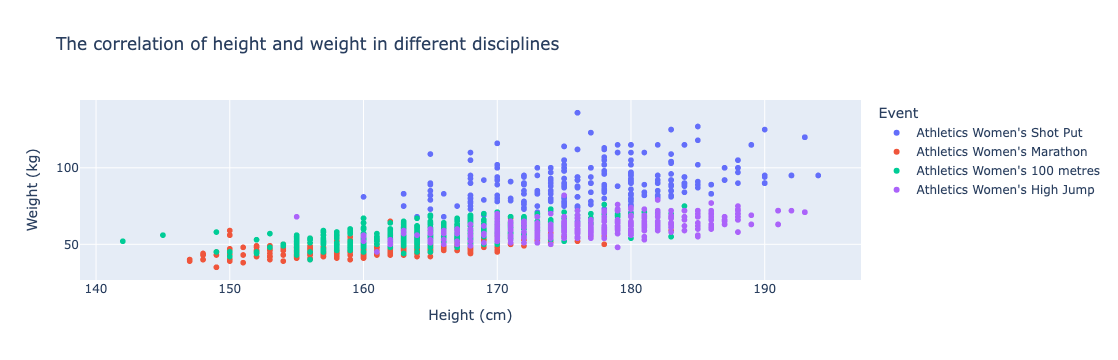

In [41]:
events_to_plot = ['Athletics Women\'s 100 metres', 
                  'Athletics Women\'s Marathon',
                  'Athletics Women\'s Shot Put',
                  'Athletics Women\'s High Jump']

plot_data = athletics_clean[athletics_clean['Event'].isin(events_to_plot)]

fig = px.scatter(plot_data, 
                 x='Height', 
                 y='Weight', 
                 color='Event',
                 hover_data=['Name', 'Year', 'Medal'],
                 title='The correlation of height and weight in different disciplines',
                 labels={'Height': 'Height (cm)', 'Weight': 'Weight (kg)'})

fig.show()

In [42]:
athletics_clean.to_csv('data/athletics_clean.csv', index=False)
print("data saved")

data saved
